In [1]:
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# Add parent directory to sys.path
parent_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_path not in sys.path:
    sys.path.append(parent_path)

# Import stratified_k_fold_cross_validation function from src/models.py
from src.models import stratified_k_fold_cross_validation

- The input to the problem is credit card customer information (columns like `Gender`, `Customer_Age`, etc.)
- The output of the problem is whether the customer's account has been closed/still exists (column `Attrition_Flag`)
    - The `Attrition_Flag` column has only two values: `Attrited Customer` and `Existing Customer`, which have been encoded as `0` and `1`.
- We have: 
    - The `Logistic regression` model is a classification model, mainly used for binary classification: 2 classes and returns probability.
    - And the problem requirement is to classify accounts into `0` and `1` (staying and not staying). <br>
➡ The `Logistic regression` model is appropriate.

Load preprocessed data from `data/processed/BankChurner.csv`

In [2]:
DATA_PATH = "../data/processed/BankChurners.csv"
data = np.genfromtxt(DATA_PATH, delimiter=',', skip_header=1)
data.shape

(10127, 25)

The output is the last column `Attrition_Flag` and the previous columns are inputs.

In [3]:
X = data[:, :-1]             # Input is all columns except the last one
y = data[:, -1].astype(int)  # Output is the last column "Attrition_Flag"

print(f"X shape={X.shape}, y shape={y.shape}")

X shape=(10127, 24), y shape=(10127,)


- With `x` as input data and `y` as output data.
- Use `K-fold Cross-Validation` method to split data into folds. In each iteration:
    - Use k - 1 folds for training.
    - Use 1 remaining fold for testing.

**Note**: Since the output data in the `Attrition_Flag` column is imbalanced, with the ratio found in the `01_data_exploration.py` file: <br>
    - `"Attrited Customer"`: $16.1\%$ <br>
    - `"Existing Customer"`: $83.9\%$

➡ Use the improved version `Stratified K-Fold Cross-Validation` to reduce imbalance, specifically:
- Each fold is split so that the class ratio in the fold is similar to the overall dataset ratio.
- Each fold has an output variable $y = 1$ ratio of $83.9\%$ and $y = 0$ ratio of $16.1\%$.

The evaluation metrics function takes 2 quantities: true output `y_true` and predicted output by the model `y_pred`:
- Called for each fold running Logistic Regression model and evaluated using four main metrics: Accuracy, Precision, Recall, and F1-Score:
    - `Accuracy`: Overall accuracy
        $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
    - `Precision`: Among customers predicted to churn, how many are correct.
        $$\text{Precision} = \frac{TP}{TP + FP}$$
    - `Recall`: Among churned customers, how many were found.
        $$\text{Recall} = \frac{TP}{TP + FN}$$
    - `F1-Score`: This is the harmonic mean of Precision and Recall.
        $$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$
    - Notation explanation:
        - TP (True Positive)

            - Number of customers who actually left (y_true = 1)

            - And the model also predicted left (y_pred = 1)

            - This is the case of correctly detecting customers about to leave → very important.

        - TN (True Negative)

            - Number of customers who actually stayed (y_true = 0)

            - And the model predicted stayed (y_pred = 0)

            - Model "at ease", no retention action triggered → correct.

        - FP (False Positive)

            - Customer actually stayed (y_true = 0)

            - But model predicted left (y_pred = 1)

            - Meaning false alarm:

            - Consequence: May be wrong but doesn't cause major harm.

        - FN (False Negative)

            - Customer actually left (y_true = 1)

            - But model predicted stayed (y_pred = 0)

            - This is the most dangerous case:

            - Bank misses customers about to leave → Causes major consequences.

**Logistic Regression** model, using **Batch Gradient Descent** to optimize **Binary Cross-Entropy (Log Loss)** loss function.

Goal:

$$P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

where:

* $\mathbf{w}$: weight vector
* $b$: bias
* $\sigma(z)$: sigmoid function - maps to probability in range (0, 1)
    $$\sigma(z) = \frac{1}{1 + e^{-z}}$$
    $$z = \mathbf{w}^T \mathbf{x} + b$$
In the given problem:

* $y = 1$: customer churned
* $y = 0$: customer stayed

The model learns parameters $(\mathbf{w}, b)$ such that the predicted probability $P(y = 1 \mid \mathbf{x})$ is close to the true label.

The model provides two types of predictions: <br>
    - Probability of customer churning using `predict_proba` function based on `_sigmoid` function - $\sigma(z)$ <br>. 
    - Whether customer belongs to staying/leaving category through `predict` function. Set `threshold = 0.3` low to be able to 'catch' more customers who will leave, helping to minimize missing customers causing less damage.

In [4]:
trained_model, accuracies, precisions, recalls, f1s, roc_data_list = stratified_k_fold_cross_validation(
    X, y, k=5, learning_rate=0.1, num_iterations=2000)

Fold 1: Acc=0.8899, Precision=0.6396, Recall=0.7239, F1=0.6791, AUC=0.9193
Fold 2: Acc=0.9097, Precision=0.7025, Recall=0.7607, F1=0.7305, AUC=0.9454
Fold 3: Acc=0.8933, Precision=0.6446, Recall=0.7477, F1=0.6923, AUC=0.9272
Fold 4: Acc=0.9156, Precision=0.7081, Recall=0.8062, F1=0.7540, AUC=0.9535
Fold 5: Acc=0.9052, Precision=0.6812, Recall=0.7692, F1=0.7225, AUC=0.9343

--- AVERAGE RESULTS ---
Accuracy :  0.9027
Precision:  0.6752
Recall   :  0.7615
F1-score :  0.7157


Plot the **Receiver Operating Characteristic** (ROC) curve to evaluate the model's classification capability

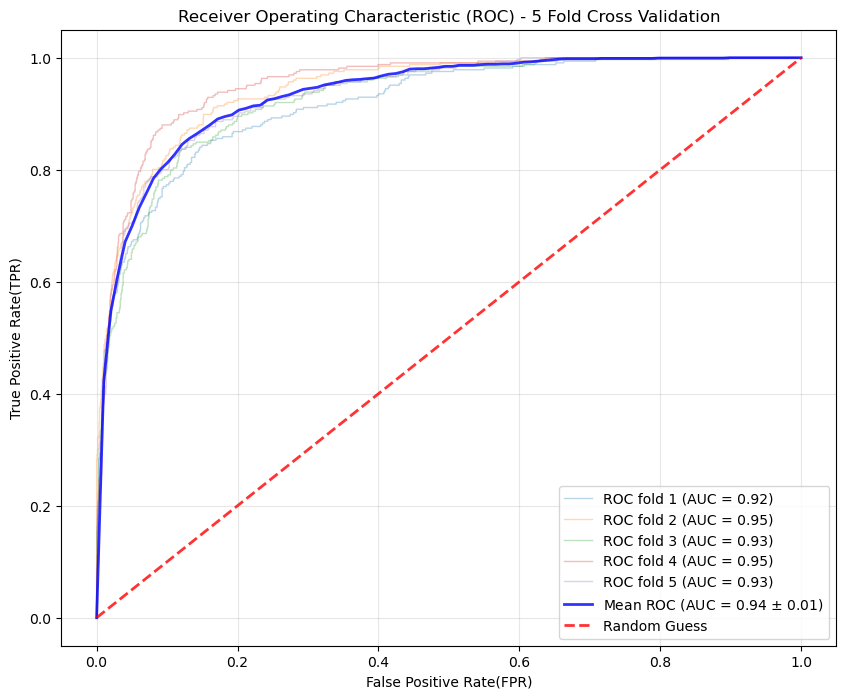

In [5]:
plt.figure(figsize=(10, 8))

# Variables to calculate Mean ROC
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []

# Loop through each element in roc_data_list to plot
for i, (fpr, tpr, auc) in enumerate(roc_data_list):
    # Save AUC to calculate average
    aucs.append(auc)
    
    # Interpolate TPR to calculate average later
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    # Plot ROC curve for current Fold (thin, faded line)
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'ROC fold {i+1} (AUC = {auc:.2f})')

# Calculate and plot mean ROC curve
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0 # Ensure it ends at (1,1)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs)

# Plot mean curve (bold, blue)
plt.plot(mean_fpr, mean_tpr, color='b',
         label=rf'Mean ROC (AUC = {mean_auc:.2f} $\pm$ {std_auc:.2f})',
         lw=2, alpha=.8)

plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Random Guess', alpha=.8)
plt.xlim([-0.05, 1.05])
plt.ylim([-0.05, 1.05])
plt.xlabel('False Positive Rate(FPR)')
plt.ylabel('True Positive Rate(TPR)')
plt.title('Receiver Operating Characteristic (ROC) - 5 Fold Cross Validation')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Save and display
plt.savefig("roc_curve_plot.png", bbox_inches="tight")
plt.show()

➡️ **Observations**:

- **Faded lines:** Represent results of individual Folds to check stability.
    - Very close to each other, showing the model has high stability with consistent results across different test iterations

- **Bold blue line:** Is the average (**Mean ROC**), representing the model's overall performance.
    - Far from the **red dashed line** shows that this Logistic Regression model's ability to classify between "Churned" and "Staying" customers is much better than random guessing.

- **Mean AUC:** Area under the mean curve, used to compare with random curve (Red dashed line - AUC 0.5).
    - Achieves high result of **0.94** → showing excellent classification performance.

Plot evaluation metrics across each fold

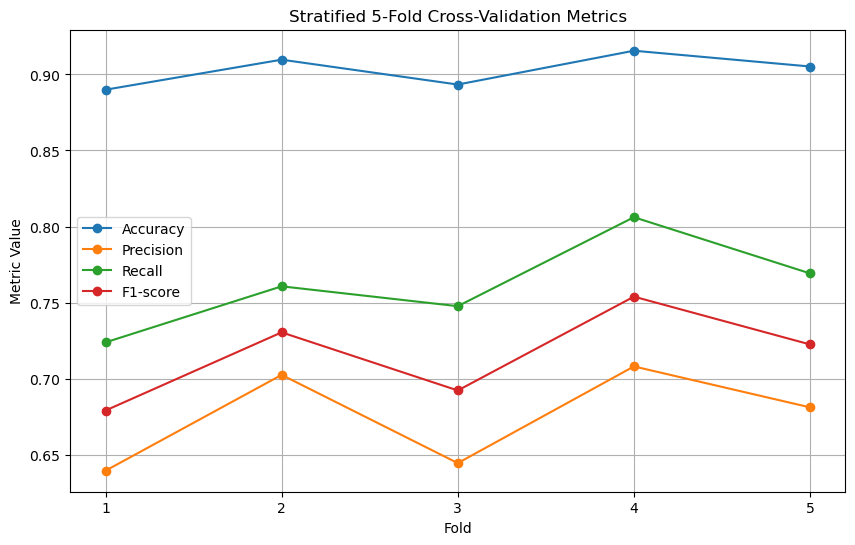

In [6]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
values = [
    accuracies,
    precisions,
    recalls,
    f1s
]

plt.figure(figsize=(10,6))
for i, metric in enumerate(metrics):
    plt.plot(range(1, len(values[i]) + 1), values[i], marker='o', label=metric)

plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Fold")
plt.ylabel("Metric Value")
plt.title("Stratified 5-Fold Cross-Validation Metrics")
plt.legend()
plt.grid(True)

plt.savefig("metrics_plot.png", bbox_inches="tight") 
plt.show()

➡️ **Observations**:

🔍 `Accuracy`

- Model accuracy is often quite high due to imbalanced data (84% customers staying).

- Accuracy is not the most important metric because the model can predict all "no churn" and still achieve a high score.

🔍 `Precision`

- Precision reflects the quality of predicting whether a customer will churn or not.

- High Precision means the model has few false alarms → not wasting cost on retaining wrong targets.

🔍 `Recall` (Most Important)

- Recall represents the model's ability to correctly catch churned customers.

- If Recall is low → model misses churned customers → causes major business damage.

🔍 `F1-score`

- Harmonic mean of Precision and Recall → balances 2 factors.

- High F1-score shows the model operates stably and is suitable for the above problem.